# Evaluation and Visualization of Segmentation and Detection Results

This notebook evaluates the trained VQ model on the validation set and visualizes segmentation and detection results.

In [1]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

os.environ['CUDA_VISIBLE_DEVICES'] = "1"

from dataset.build import build_dataset
from tokenizer.vq_model import VQ_models

# Set paths and parameters (from train_vq.sh)
ckpt_path = "/qumulo/shared_data/aofei_summer/RegTok/source/RegTok_no_quant_01/000-RegTok/checkpoints/0005220.pt"  # <-- fill with actual checkpoint filename
data_path = "/qumulo/shared_data/aofei_summer/data/BiomedParse/amos22/amos22/CT/train"
segmentation_path = "/qumulo/shared_data/aofei_summer/data/BiomedParse/amos22/amos22/CT/train_mask"
annotation_json = "/qumulo/shared_data/aofei_summer/data/BiomedParse/amos22/amos22/CT/train.json"
vq_model_name = "RegTok"
image_size = 192
batch_size = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
# Define transforms (should match training)
mask_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])
dataset_name = 'biomed_seg'
# Build dataset and split
dataset = build_dataset(
    type("Args", (), {
        "dataset": dataset_name,
        "data_path": data_path,
        "segmentation_path": segmentation_path,
        "annotation_json": annotation_json,
        "image_size": image_size
    })(),
    transform=None,
    mask_transform=mask_transform,
    clip_preprocess=None
)
val_ratio = 0.1
total_len = len(dataset)
val_len = int(total_len * val_ratio)
train_len = total_len - val_len
_, val_dataset = torch.utils.data.random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=lambda batch: (
    torch.cat([item[0] for item in batch], dim=0),
    [item[1].squeeze(1) for item in batch],
    [item[2] for item in batch]
))

Total images: 30395, total annotations: 108704
Filtered annotations: 108704


In [3]:
getattr(dataset, "num_classes", 2)

17

In [4]:
# Load model
vq_model = VQ_models[vq_model_name](
    codebook_size=1024,
    num_stages=3,
    codebook_embed_dim=64,
    dropout_p=0.0,
    kmeans=False,
    use_quantization=True,
    num_classes=getattr(dataset, "num_classes", 2)
)
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
# Load only matching keys (trainable params may be subset)
missing, unexpected = vq_model.load_state_dict(ckpt["model"], strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
vq_model = vq_model.to(device)
vq_model.eval()

dataset.clip_preprocess = vq_model.unimed_preprocess

Codebook initialized with uniform distribution, allow gradient: False
Upsample mode: conv
Missing keys: ['image_encoder.class_embedding', 'image_encoder.positional_embedding', 'image_encoder.proj', 'image_encoder.conv1.weight', 'image_encoder.ln_pre.weight', 'image_encoder.ln_pre.bias', 'image_encoder.transformer.resblocks.0.attn.in_proj_weight', 'image_encoder.transformer.resblocks.0.attn.in_proj_bias', 'image_encoder.transformer.resblocks.0.attn.out_proj.weight', 'image_encoder.transformer.resblocks.0.attn.out_proj.bias', 'image_encoder.transformer.resblocks.0.ln_1.weight', 'image_encoder.transformer.resblocks.0.ln_1.bias', 'image_encoder.transformer.resblocks.0.mlp.c_fc.weight', 'image_encoder.transformer.resblocks.0.mlp.c_fc.bias', 'image_encoder.transformer.resblocks.0.mlp.c_proj.weight', 'image_encoder.transformer.resblocks.0.mlp.c_proj.bias', 'image_encoder.transformer.resblocks.0.ln_2.weight', 'image_encoder.transformer.resblocks.0.ln_2.bias', 'image_encoder.transformer.resbloc

In [5]:
ckpt["model"].keys()

dict_keys(['region_perceiver.region_queries', 'region_perceiver.region_position_embed.weight', 'region_perceiver.init_cross_attn.norm_media.weight', 'region_perceiver.init_cross_attn.norm_media.bias', 'region_perceiver.init_cross_attn.norm_latents.weight', 'region_perceiver.init_cross_attn.norm_latents.bias', 'region_perceiver.init_cross_attn.to_q.weight', 'region_perceiver.init_cross_attn.to_kv.weight', 'region_perceiver.init_cross_attn.to_out.weight', 'region_perceiver.init_cross_norm.weight', 'region_perceiver.init_cross_norm.bias', 'region_perceiver.init_ff.0.weight', 'region_perceiver.init_ff.0.bias', 'region_perceiver.init_ff.1.weight', 'region_perceiver.init_ff.3.weight', 'region_perceiver.init_ff_norm.weight', 'region_perceiver.init_ff_norm.bias', 'region_perceiver.conv_adapters.0.conv.weight', 'region_perceiver.conv_adapters.0.conv.bias', 'region_perceiver.conv_adapters.1.conv.weight', 'region_perceiver.conv_adapters.1.conv.bias', 'region_perceiver.conv_adapters.2.conv.weight'

In [6]:
ckpt.keys()

dict_keys(['model', 'steps', 'args'])

In [7]:
# Utility for visualization
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def show_segmentation(img, gt_mask, pred_mask, idx_to_class=None, num_classes=None):
    # img: (H, W, 3), gt_mask: (H, W), pred_mask: (H, W)
    # Ensure img is (H, W, 3)
    if img.shape[0] == 3 and img.shape[-1] != 3:
        img = np.transpose(img, (1, 2, 0))
    elif img.shape[-1] != 3:
        img = np.moveaxis(img, 0, -1)
    # Ensure gt_mask and pred_mask are (H, W)
    if gt_mask.ndim == 3 and gt_mask.shape[0] == 1:
        gt_mask = gt_mask[0]
    if pred_mask.ndim == 3 and pred_mask.shape[0] == 1:
        pred_mask = pred_mask[0]
    # Resize gt_mask and pred_mask to match img spatial size if needed
    from skimage.transform import resize
    H, W = img.shape[:2]
    if gt_mask.shape != (H, W):
        gt_mask = resize(gt_mask, (H, W), order=0, preserve_range=True, anti_aliasing=False).astype(gt_mask.dtype)
    if pred_mask.shape != (H, W):
        pred_mask = resize(pred_mask, (H, W), order=0, preserve_range=True, anti_aliasing=False).astype(pred_mask.dtype)
    # Colormap and legend
    if num_classes is None:
        num_classes = int(np.max([gt_mask.max(), pred_mask.max()])) + 1
    cmap = plt.get_cmap('tab20', num_classes)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img)
    axs[0].set_title("Image")
    im1 = axs[1].imshow(gt_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
    axs[1].set_title("GT Mask")
    im2 = axs[2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
    axs[2].set_title("Pred Mask")
    for ax in axs:
        ax.axis("off")
    # Add legend for classes
    handles = []
    class_names = [str(i) for i in range(num_classes)] if idx_to_class is None else [idx_to_class.get(i, str(i)) for i in range(num_classes)]
    for i in range(num_classes):
        handles.append(Line2D([0], [0], marker='s', color='w', label=class_names[i],
                              markerfacecolor=cmap(i), markersize=10))
    axs[2].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

def show_detection(img, pred_boxes, pred_classes=None, class_names=None, color_map=None):
    # img: (H, W, 3)
    if img.shape[0] == 3 and img.shape[-1] != 3:
        img = np.transpose(img, (1, 2, 0))
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    if color_map is None:
        color_map = plt.get_cmap('tab20')
    for i, box in enumerate(pred_boxes):
        x1, y1, x2, y2 = box
        color = color_map(pred_classes[i] % 20) if pred_classes is not None else 'r'
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        if pred_classes is not None and class_names is not None:
            ax.text(x1, y1, class_names[pred_classes[i]], color='yellow', fontsize=12, bbox=dict(facecolor=color, alpha=0.5))
    # Add legend for detection classes
    if pred_classes is not None and class_names is not None:
        unique_classes = np.unique(pred_classes)
        handles = []
        for c in unique_classes:
            handles.append(Line2D([0], [0], marker='s', color='w', label=class_names[c],
                                  markerfacecolor=color_map(c % 20), markersize=10))
        ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [8]:
dice_loss

NameError: name 'dice_loss' is not defined

  0%|          | 0/1520 [00:00<?, ?it/s]

tensor([ 6, 13,  2, 15]) tensor([0, 1, 2, 3])


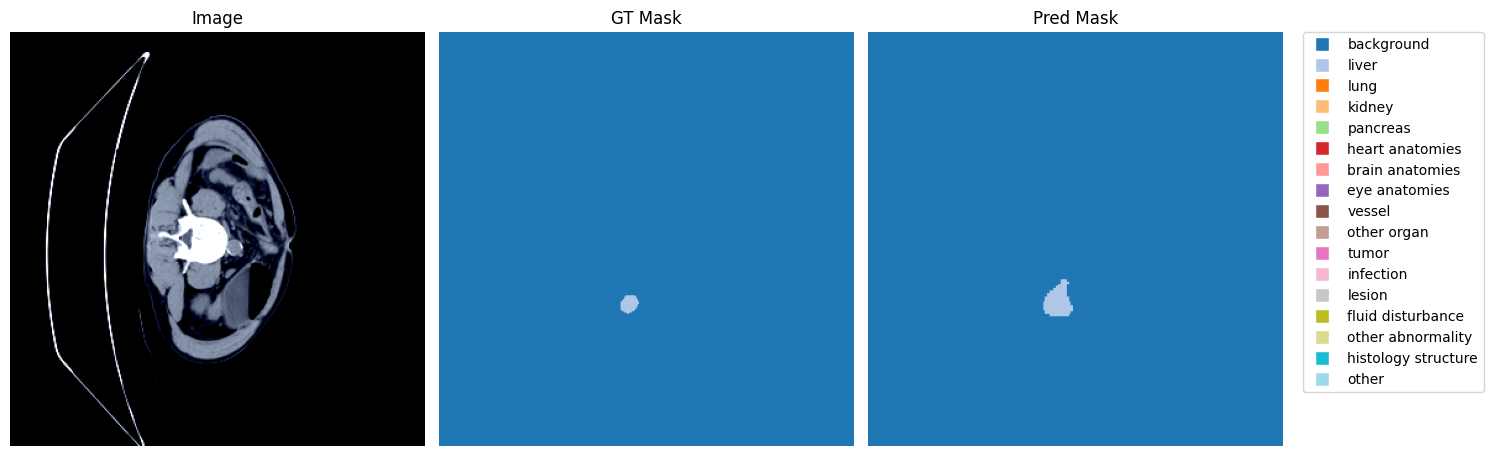

tensor([-10.2667,  -5.4629, -10.3948,  14.8701,  -1.0012, -10.1920, -10.7155,
        -10.9550,  -1.1044,  -0.6040,  -9.9510, -10.4670, -10.8413, -11.1131,
        -10.4079, -10.7352, -10.6355, -10.3120], device='cuda:0')
Predicted class for segment 0: kidney (index 3)
Ground truth class for segment 0: kidney (index 3)


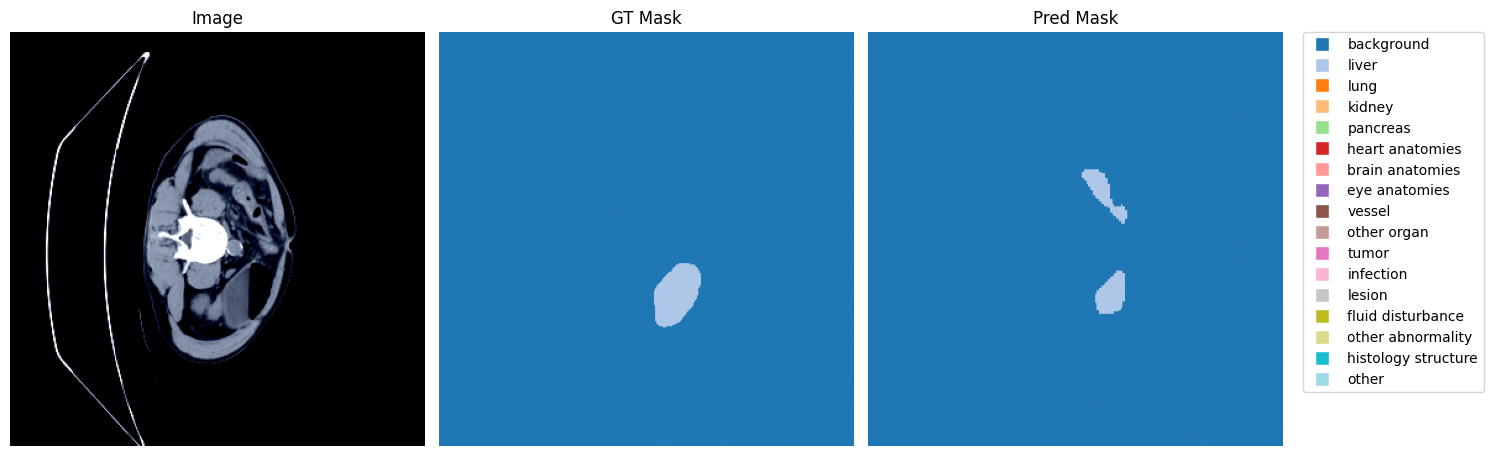

tensor([-11.1008,  -7.1294, -11.2093,  -2.3119,  -3.4027, -11.3020, -11.5541,
        -11.1227,  -2.1271,  13.4954, -11.0069, -10.9761, -11.2940, -11.6921,
        -10.9300, -10.7864, -11.3278, -10.8096], device='cuda:0')
Predicted class for segment 1: other organ (index 9)
Ground truth class for segment 1: other organ (index 9)


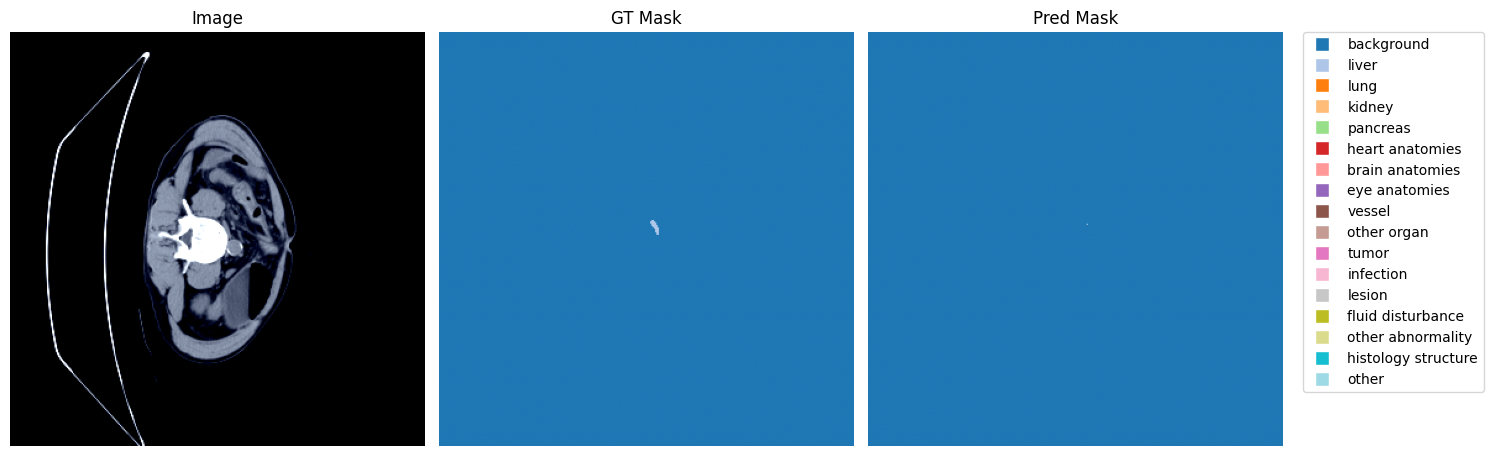

tensor([-10.0171,  -4.0316, -10.1433,  -6.7404,  -4.5341, -10.8918, -10.6559,
        -11.0514,  24.1225,  -3.1900, -10.4056, -10.5695, -10.1193,  -9.6083,
        -10.1980,  -9.1114, -11.3692, -11.0081], device='cuda:0')
Predicted class for segment 2: vessel (index 8)
Ground truth class for segment 2: vessel (index 8)


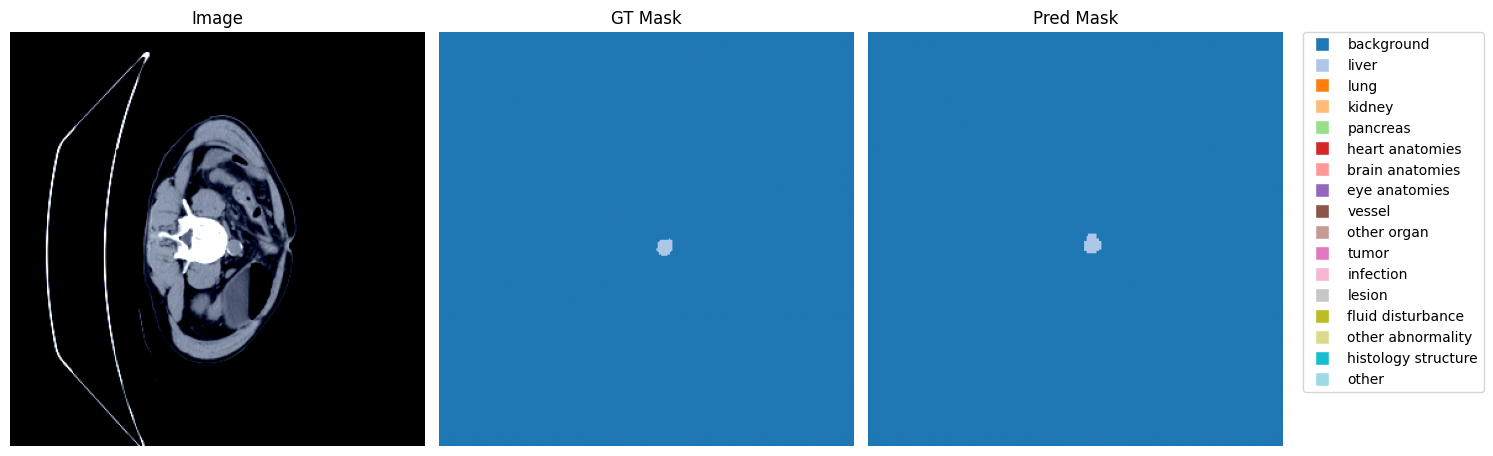

  0%|          | 0/1520 [00:03<?, ?it/s]

tensor([-10.4012,  -4.0928, -10.2988,  -3.6026,  -1.7552, -10.3181, -11.4998,
        -11.2851,  21.1026,  -3.1339, -10.5179, -10.5293, -10.6375, -10.2721,
        -10.6750,  -9.6670, -11.2767, -11.0821], device='cuda:0')
Predicted class for segment 3: vessel (index 8)
Ground truth class for segment 3: vessel (index 8)


In [8]:
# Run evaluation and visualize a few samples
num_visualize = 1
visualized = 0

# Define class names for legend (from your annotation)
class_names = [
    "background", "liver", "lung", "kidney", "pancreas", "heart anatomies", "brain anatomies",
    "eye anatomies", "vessel", "other organ", "tumor", "infection", "lesion",
    "fluid disturbance", "other abnormality", "histology structure", "other"
]
num_classes = len(class_names)

from tokenizer.criterion import hungarian_assign

for imgs, masks, class_labels in tqdm(val_loader):
    imgs = imgs.to(device)
    masks = [i.to(device) for i in masks]
    # classs_labels = [c.to(device) for c in class_labels]
    with torch.no_grad():
        outputs = vq_model(
            imgs, do_quantize=False, mask_labels=masks, class_labels=[c.to(device) for c in class_labels], loss_type="dice_bce"
        )
        # if len(outputs) == 7:
            # dec_mask, diff_quan, dice_loss, bce_loss, cls_loss, seg_logits, class_logits = outputs
        dec, diff, dice_loss, bce_loss, cls_loss, seg_logits, class_logits, hierarchical_codes, hierarchical_masks, hierarchical_gt_masks, hierarchical_losses, quantization_losses, \
            total_quantization_loss, dice_loss_normal, dice_loss_quant, cls_loss_normal, cls_loss_quant, distill_loss, quantizer_info = outputs
        # else:
        #     dec_mask, diff_quan, seg_loss, cls_loss = outputs
        #     seg_logits = dec_mask
        #     class_logits = None

        # Hungarian matching to get best pred_mask <-> gt_mask assignment
        # seg_logits: (B, N, H, W), masks: list of (num_gt, H, W)
        indices,_ , _, _ = hungarian_assign(seg_logits, masks, class_logits, [c.to(device) for c in class_labels], num_classes=num_classes, eos_coef=0.1, loss_type="dice_bce")
    
    imgs_np = imgs.cpu().numpy()
    for b in range(imgs_np.shape[0]):
        img = np.clip((imgs_np[b].transpose(1, 2, 0) * 0.5 + 0.5), 0, 1)
        gt_masks = masks[b].cpu().numpy()  # (num_gt, H, W)
        pred_masks_all = seg_logits[b].cpu().numpy()  # (N, H, W)
        # Get assignment for this sample
        pred_idx, gt_idx = indices[b]
        print(pred_idx, gt_idx)
        for j, (p_idx, g_idx) in enumerate(zip(pred_idx.tolist(), gt_idx.tolist())):
            gt_mask = gt_masks[g_idx]
            pred_mask_logits = pred_masks_all[p_idx]
            # print(pred_mask_logits, "pred_logits")
            pred_mask = (pred_mask_logits > 0).astype(np.uint8)  # threshold for binary mask
            # Optionally, use argmax for multi-class, but here each mask is binary
            show_segmentation(
                img, gt_mask, pred_mask,
                idx_to_class={i: class_names[i] for i in range(num_classes)},
                num_classes=num_classes
            )
            if class_logits is not None:
                pred_class_idx = class_logits[b][p_idx].argmax().item()
                print(class_logits[b][p_idx])
                pred_class_name = class_names[pred_class_idx]
                print(f"Predicted class for segment {j}: {pred_class_name} (index {pred_class_idx})")
                gt_class_idx = class_labels[b][g_idx].item()
                gt_class_name = class_names[gt_class_idx]
                print(f"Ground truth class for segment {j}: {gt_class_name} (index {gt_class_idx})")
        visualized += 1
        if visualized >= num_visualize:
            break
        # if visualized >= num_visualize:
        #     break
    if visualized >= num_visualize:
        break

## Load Quantization Module from Separate Checkpoint

We load the quantizer/codebook weights from a different checkpoint and inject them into the region perceiver's quantizer.

In [5]:
vq_model.quantizer

VectorQuantizerST(
  (embedding): Embedding(1024, 64)
)

In [7]:
quantizer_state_dict

{}

In [9]:
# Path to quantizer checkpoint (update as needed)
quant_ckpt_path = "/qumulo/shared_data/aofei_summer/RegTok/source/RegTok_quant/039-RegTok/checkpoints/0010440.pt"

# Load quantizer checkpoint
quant_ckpt = torch.load(quant_ckpt_path, map_location="cpu", weights_only=False)

# Copy quantizer weights into the loaded model's quantizer
# quantizer_state_dict = {}
# for k, v in quant_ckpt['model'].items():
#     print(k)
#     if k.startswith('region_perceiver.quantizer.') or k.startswith('region_perceiver.0.quantizer.'):
#         # Remove prefix to match current model
#         new_k = k.replace('region_perceiver.', '')
#         quantizer_state_dict[new_k] = v

# Load into region perceiver's quantizer
missing, unexpected = vq_model.load_state_dict(quant_ckpt['model'], strict=False)
print('Loaded quantizer weights from:', quant_ckpt_path)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

Loaded quantizer weights from: /qumulo/shared_data/aofei_summer/RegTok/source/RegTok_quant/039-RegTok/checkpoints/0010440.pt
Missing keys: ['image_encoder.class_embedding', 'image_encoder.positional_embedding', 'image_encoder.proj', 'image_encoder.conv1.weight', 'image_encoder.ln_pre.weight', 'image_encoder.ln_pre.bias', 'image_encoder.transformer.resblocks.0.attn.in_proj_weight', 'image_encoder.transformer.resblocks.0.attn.in_proj_bias', 'image_encoder.transformer.resblocks.0.attn.out_proj.weight', 'image_encoder.transformer.resblocks.0.attn.out_proj.bias', 'image_encoder.transformer.resblocks.0.ln_1.weight', 'image_encoder.transformer.resblocks.0.ln_1.bias', 'image_encoder.transformer.resblocks.0.mlp.c_fc.weight', 'image_encoder.transformer.resblocks.0.mlp.c_fc.bias', 'image_encoder.transformer.resblocks.0.mlp.c_proj.weight', 'image_encoder.transformer.resblocks.0.mlp.c_proj.bias', 'image_encoder.transformer.resblocks.0.ln_2.weight', 'image_encoder.transformer.resblocks.0.ln_2.bias',

## Run Validation and Collect Quantization Info

We run inference on the validation set and collect quantizer outputs for interpretability analysis.

In [16]:
quantizer_infos = []
all_pred_classes = []
all_gt_classes = []
for imgs, masks, class_labels in tqdm(val_loader):
    imgs = imgs.to(device)
    masks = [i.to(device) for i in masks]
    with torch.no_grad():
        outputs = vq_model(
            imgs, do_quantize=True, mask_labels=masks, class_labels=[c.to(device) for c in class_labels], loss_type="dice_bce"
        )
        dec, diff, dice_loss, bce_loss, cls_loss, seg_logits, class_logits, hierarchical_codes, hierarchical_masks, hierarchical_gt_masks, hierarchical_losses, quantization_losses, \
            total_quantization_loss, dice_loss_normal, dice_loss_quant, cls_loss_normal, cls_loss_quant, distill_loss, quantizer_info = outputs
        quantizer_infos.append(quantizer_info)
        # print(quantizer_info)
        # Optionally collect class predictions for analysis
        if class_logits is not None:
            all_pred_classes.append([logit.argmax().item() for logit in class_logits[0]])
            all_gt_classes.append([c.item() for c in class_labels[0]])

100%|█████████▉| 1519/1520 [06:38<00:00,  3.82it/s]


ValueError: not enough values to unpack (expected 3, got 2)

In [17]:
len(quantizer_infos)

1519

## Quantization Interpretability Analysis

We analyze the quantizer outputs, including codebook usage, assignment distributions, and code index patterns.

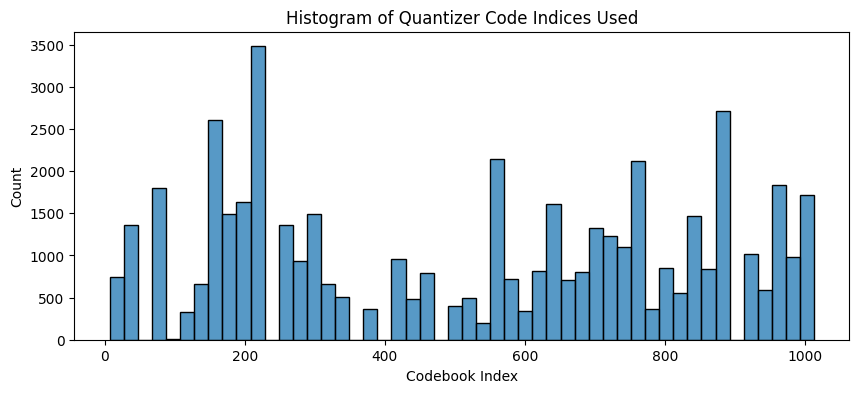

Codebook usage ratio: 0.107 (110/1024)


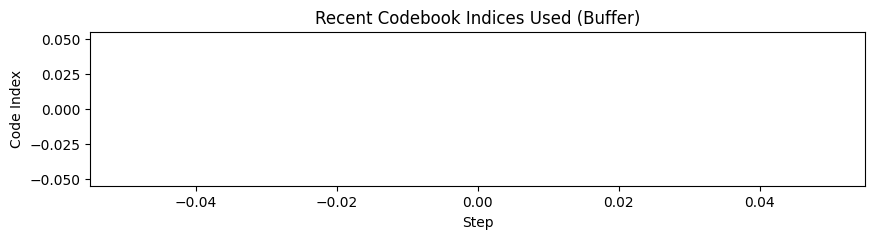

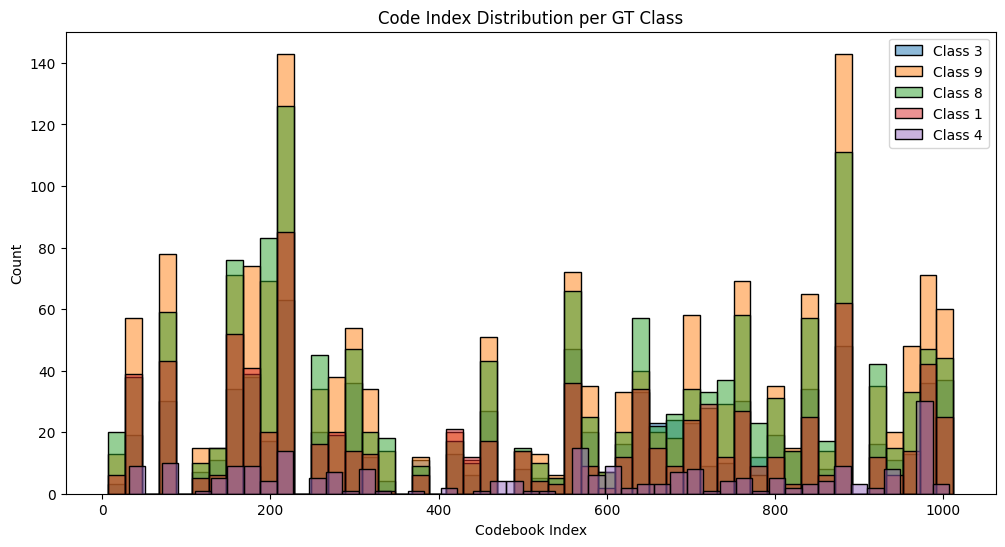

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Codebook usage histogram
all_indices = torch.cat([q['indices'].cpu().reshape(-1) for q in quantizer_infos], dim=0).numpy()
plt.figure(figsize=(10,4))
sns.histplot(all_indices, bins=50, kde=False)
plt.title('Histogram of Quantizer Code Indices Used')
plt.xlabel('Codebook Index')
plt.ylabel('Count')
plt.show()

# 2. Codebook usage ratio
unique_codes = np.unique(all_indices)
usage_ratio = len(unique_codes) / vq_model.region_perceiver.quantizer.n_e
print(f'Codebook usage ratio: {usage_ratio:.3f} ({len(unique_codes)}/{vq_model.region_perceiver.quantizer.n_e})')

# 3. Visualize codebook usage buffer if available
if hasattr(vq_model.region_perceiver.quantizer, 'codebook_used'):
    used = vq_model.region_perceiver.quantizer.codebook_used.cpu().numpy()
    used = used[used >= 0]
    plt.figure(figsize=(10,2))
    plt.plot(used, '.', alpha=0.5)
    plt.title('Recent Codebook Indices Used (Buffer)')
    plt.xlabel('Step')
    plt.ylabel('Code Index')
    plt.show()

# 4. If assignment_probs present, analyze soft assignment entropy
if any(q.get('assignment_probs', None) is not None for q in quantizer_infos):
    entropies = []
    for q in quantizer_infos:
        prob = q.get('assignment_probs', None)
        if prob is not None:
            entropy = -(prob * (prob.clamp_min(1e-8).log())).sum(dim=1).mean().item()
            entropies.append(entropy)
    if entropies:
        plt.figure()
        plt.hist(entropies, bins=30)
        plt.title('Assignment Probability Entropy (Soft Assignment)')
        plt.xlabel('Entropy')
        plt.ylabel('Count')
        plt.show()

# 5. Optionally, analyze code index patterns per class (if class labels collected)
if all_pred_classes and all_gt_classes:
    from collections import defaultdict
    class_to_indices = defaultdict(list)
    for idxs, gts in zip([q['indices'].cpu().numpy().reshape(-1) for q in quantizer_infos], all_gt_classes):
        for code_idx, gt_class in zip(idxs, gts):
            class_to_indices[gt_class].append(code_idx)
    plt.figure(figsize=(12,6))
    for cls, idxs in class_to_indices.items():
        sns.histplot(idxs, bins=50, label=f'Class {cls}', alpha=0.5)
    plt.title('Code Index Distribution per GT Class')
    plt.xlabel('Codebook Index')
    plt.ylabel('Count')
    plt.legend()
    plt.show()